In [3]:
import numpy as np
import pylab as pl
import matplotlib.pyplot as plt
from sklearn import neighbors
from sklearn.model_selection import train_test_split
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [4]:
# USGS live earthquake feed - all earthquakes from the last 24 hours
url = "https://earthquake.usgs.gov/earthquakes/feed/v1.0/summary/all_day.geojson"
response = requests.get(url)
data = response.json()

# Conversion en DataFrame
print("Status code:", response.status_code)
df = pd.json_normalize(data["features"])

# Extraction des coordonnées
print("Nombre de séismes:", len(df))
df["longitude"] = df["geometry.coordinates"].apply(lambda x: x[0])
df["latitude"] = df["geometry.coordinates"].apply(lambda x: x[1])
df["depth_km"] = df["geometry.coordinates"].apply(lambda x: x[2])

# Sélection des colonnes utiles
df_clean = df[[
    "properties.mag",
    "properties.sig",
    "properties.nst",
    "properties.dmin",
    "properties.rms",
    "properties.gap",
    "longitude",
    "latitude",
    "depth_km"
]].copy()

# Renommage des colonnes
df_clean.columns = [
    "magnitude",
    "significance",
    "nst",
    "dmin",
    "rms",
    "gap",
    "longitude",
    "latitude",
    "depth_km"
]

print(df_clean.shape)
df_clean.head()

Status code: 200
Nombre de séismes: 204
(204, 9)


,magnitude,significance,nst,dmin,rms,gap,longitude,latitude,depth_km
0,2.169807,72,48,0.239100,0.21,176,-118.066002,33.253834,11.09
1,5.100000,400,48,3.217000,0.94,55,120.276800,-8.209900,10.00
2,0.900000,12,12,0.200000,0.40,62,-147.382000,64.967000,5.00
3,1.900000,56,39,0.300000,0.30,125,-155.406000,57.792000,78.80
4,1.670000,43,32,0.005323,0.04,53,-122.841835,38.822834,2.46


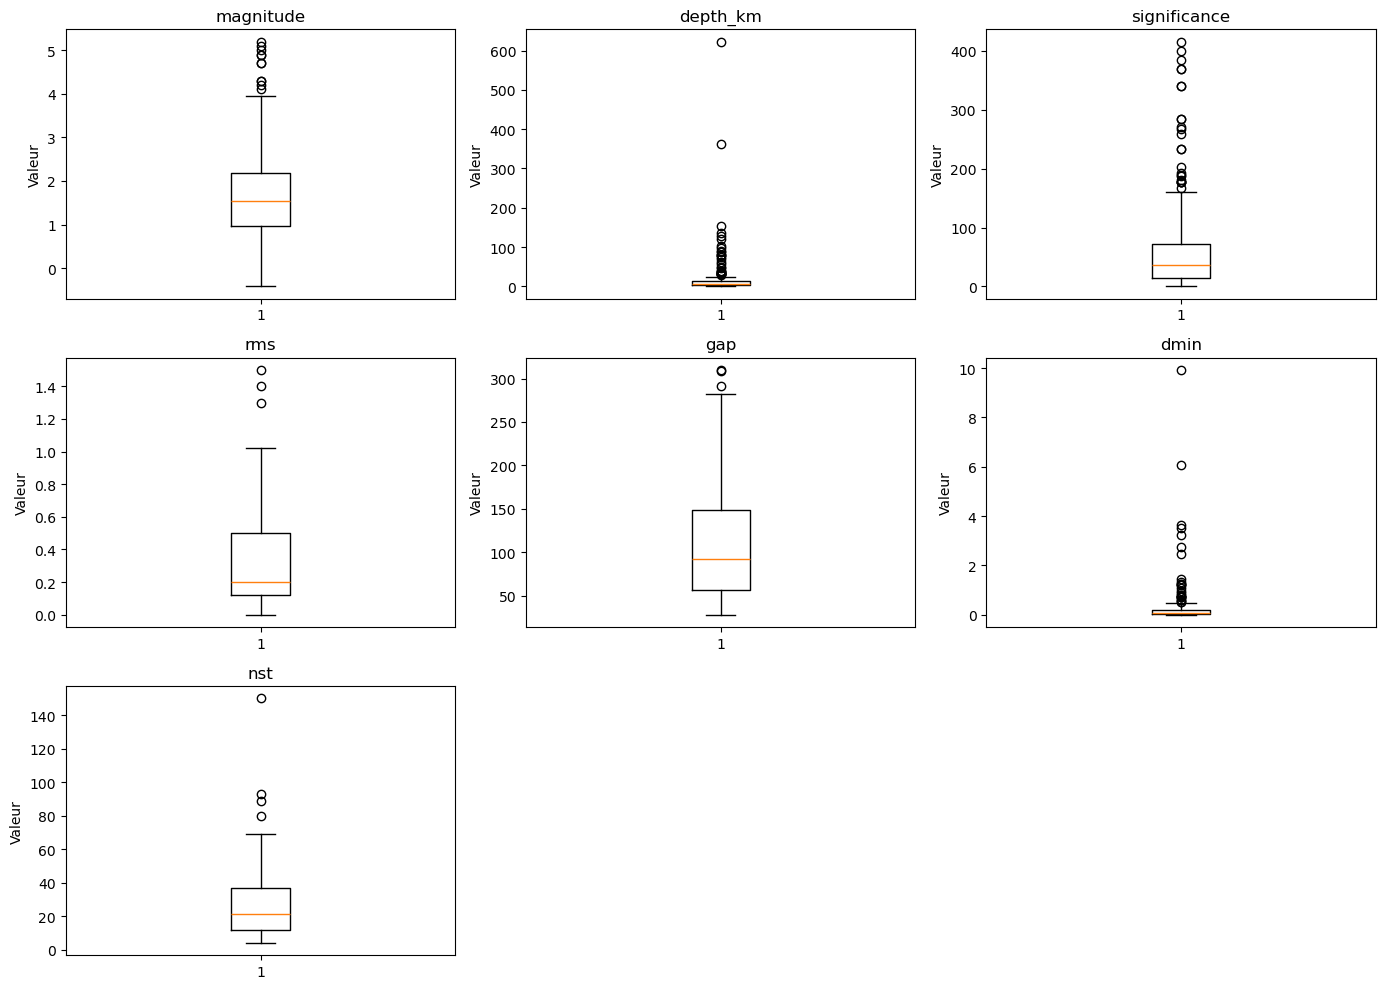

In [5]:
# Variables numériques principales à analyser
variables = ["magnitude", "depth_km", "significance", "rms", "gap", "dmin", "nst"]

plt.figure(figsize=(14, 10))
for i, variable in enumerate(variables, 1):
    plt.subplot(3, 3, i)
    plt.boxplot(df_clean[variable].dropna())
    plt.title(variable)
    plt.ylabel("Valeur")
plt.tight_layout()
plt.show()


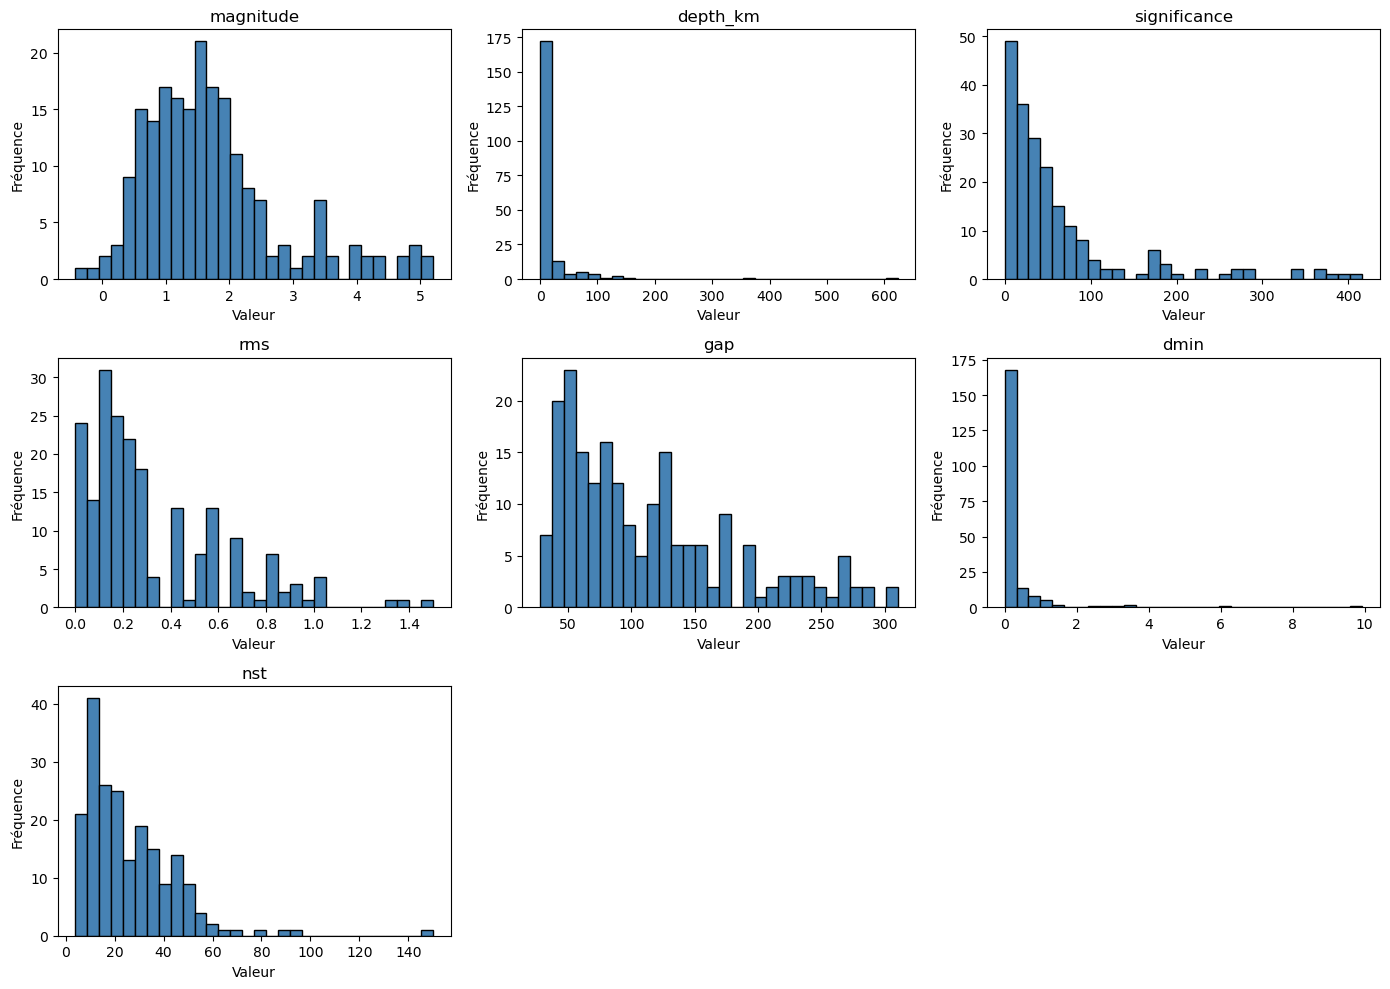

In [6]:
plt.figure(figsize=(14, 10))
for i, variable in enumerate(variables, 1):
    plt.subplot(3, 3, i)
    plt.hist(df_clean[variable].dropna(), bins=30, color='steelblue', edgecolor='black')
    plt.title(variable)
    plt.xlabel("Valeur")
    plt.ylabel("Fréquence")
plt.tight_layout()
plt.show()

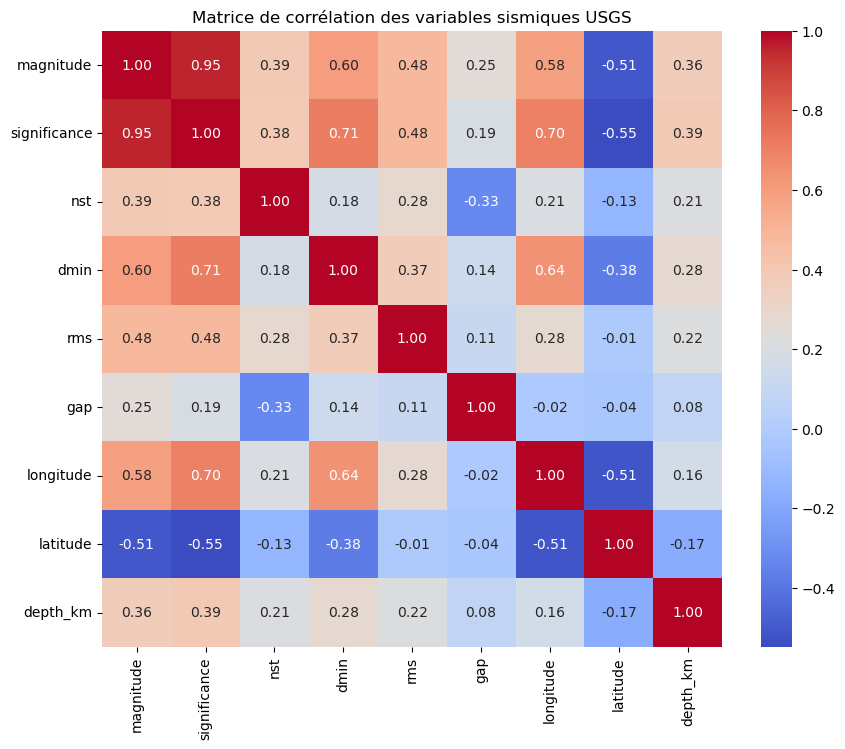

In [7]:
# Matrice de corrélation
plt.figure(figsize=(10, 8))
corr = df_clean.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matrice de corrélation des variables sismiques USGS")
plt.show()

In [8]:
# Sauvegarde du dataset
os.makedirs("data", exist_ok=True)
df_clean.to_csv("data/03_Model_PGA.csv", index=False)
print("✅ Données sauvegardées dans data/03_Model_PGA.csv")


✅ Données sauvegardées dans data/03_Model_PGA.csv


In [3]:
# data représente les prédicteurs et target la cible à prédire
X = df_clean.drop(columns=["significance"])
y = df_clean["significance"]

print(X.shape)
print(y.shape)

(243, 8)
(243,)


In [4]:
#Séparation en train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=33)

In [5]:
#Création du modèle KNN Régression
weights = 'uniform'
k_neighbors = 15
reg = neighbors.KNeighborsRegressor(k_neighbors, weights=weights)

In [6]:
#Entraînement du modèle
reg.fit(X_train, y_train)

,n_neighbors,15
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [7]:
#Évaluation sur le jeu d'entraînement
Z_train = reg.predict(X_train)
print(Z_train.shape)
score_train = reg.score(X_train, y_train)
print("Score R² du modèle sur train: " + str(score_train))

(182,)
Score R² du modèle sur train: 0.6130871576914447


In [8]:
#Évaluation sur le jeu de test
Z_test = reg.predict(X_test)
print(Z_test.shape)
score_test = reg.score(X_test, y_test)
print("Score R² du modèle sur test: " + str(score_test))

(61,)
Score R² du modèle sur test: 0.4176807262074339


In [10]:
#Prédiction sur un échantillon hors échantillon
ech = [[5.0, 20, 15, 0.5, 0.8, 120, -115.3, 33.2]]
Z = reg.predict(ech)
print(Z.shape)
print("Prédiction significance:", Z)

(1,)
Prédiction significance: [235.33333333]


C:\Users\mlnej\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(
